# **MScFE 660: Risk Management**
## Student Group: **10144**
## Group Work Project: **2**
### Members:
1. **Bianka Toneva**
2. **Dipanshu Sharma**
3. **Miklos Lammel**

## **Step- 4,5**

### **Importing the merged dataset from GWP-1**

In [3]:
# !pip install hmmlearn pgmpy==0.1.18

In [21]:
import pandas as pd
import numpy as np
np.product = np.prod  # pgmpy throwing error, using np.product
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from pgmpy.estimators import HillClimbSearch, TreeSearch, BicScore, K2Score
from pgmpy.models import BayesianModel, BayesianNetwork
import networkx as nx
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

from sklearn.preprocessing import KBinsDiscretizer

from hmmlearn.hmm import GaussianHMM

import warnings
warnings.filterwarnings("ignore")

In [22]:
# loading the merged dataset form GWP-1

merged_dataset = pd.read_csv('merged_dataset.csv', low_memory = False)
merged_dataset['Unnamed: 0'] = pd.to_datetime(merged_dataset['Unnamed: 0'])
merged_dataset.set_index('Unnamed: 0', inplace=True)

# calculating the log return for WTI
merged_dataset['WTI_log_return'] = np.log(merged_dataset['WTI'] / merged_dataset['WTI'].shift(1))
merged_dataset = merged_dataset.dropna()
merged_dataset.head()

,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST,WTI_log_return
Unnamed: 0,,,,,,,,,,
2000-11-30,45.060562,1.403604,34.264500,174.2,2.4,98.8,26.382857,116.475908,270779.25,0.038415
2000-12-31,45.395100,0.970674,28.355000,174.6,2.4,78.8,26.530500,112.725000,274451.80,-0.189306
2001-01-31,46.899555,1.031300,29.266667,175.6,-1.3,75.4,24.918571,110.125909,269867.00,0.031646
2001-02-28,55.087711,1.024682,29.644210,176.0,-1.3,80.7,23.411579,111.805499,266600.75,0.012818
2001-03-31,61.708954,0.967487,27.263182,176.1,-1.3,73.1,28.496818,113.931818,275139.20,-0.083730


In [23]:
merged_dataset.describe()

,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST,WTI_log_return
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,97.382070,1.106950,69.395165,225.799458,2.475943,191.813255,18.560469,89.481030,349660.808491,0.004706
std,23.881039,0.352992,24.848647,32.299598,1.937125,72.998130,5.704755,11.174548,61317.803631,0.121535
min,45.060562,0.060786,20.751579,174.200000,-2.100000,53.500000,10.125455,72.116819,250329.000000,-0.731104
25%,81.472279,0.857148,52.718993,201.875000,1.400000,142.175000,13.989351,80.590879,304997.637500,-0.042706
50%,91.521297,1.099083,70.217669,224.806000,2.500000,190.240000,17.412669,87.303258,332621.650000,0.013801
75%,111.328018,1.341985,89.467500,238.033250,3.500000,252.450000,22.125248,96.398176,418925.575000,0.061117
max,159.127594,2.027331,134.015714,307.374000,7.400000,384.300000,36.629167,118.966501,457773.000000,0.851699


### **Fitting Hidden Markov Model (HMM) to WTI Returns**

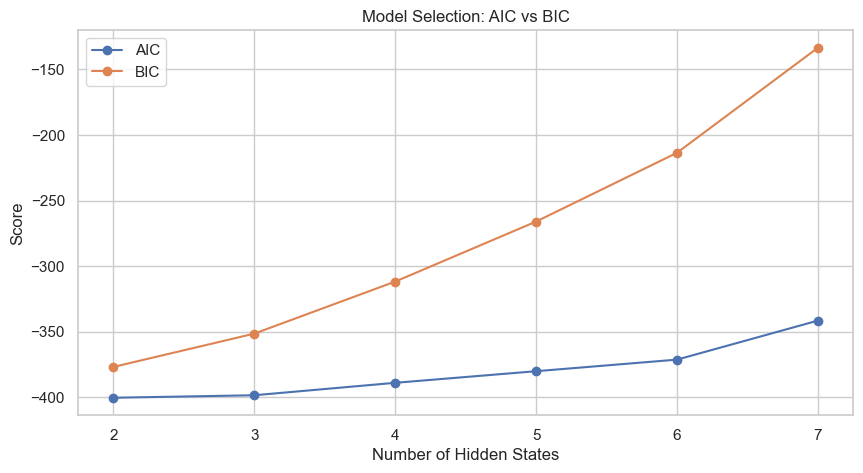

Selected number of regimes: 2


In [24]:
# log retruns
returns = merged_dataset[['WTI_log_return']].replace(np.inf, np.nan).dropna()

models = []
aics = []
bics = []
n_states_range = range(2, 8)

for n in n_states_range:
    model = GaussianHMM(n_components=n, covariance_type='full', n_iter=1000, random_state=42)
    model.fit(returns)

    log_likelihood = model.score(returns)
    n_params = n * n + 2 * n - 1  # n transition probs + n means + n variances - 1
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + np.log(len(returns)) * n_params

    models.append(model)
    aics.append(aic)
    bics.append(bic)

# plotting AIC and BIC scores
plt.figure(figsize=(10, 5))
plt.plot(n_states_range, aics, label='AIC', marker='o')
plt.plot(n_states_range, bics, label='BIC', marker='o')
plt.xlabel("Number of Hidden States")
plt.ylabel("Score")
plt.title("Model Selection: AIC vs BIC")
plt.legend()
plt.grid(True)
plt.show()

# choosing the best model
best_n = n_states_range[np.argmin(bics)]
best_model = models[np.argmin(bics)]
print(f"Selected number of regimes: {best_n}")

### **Plotting Hidden States with WTI Prices**

In [25]:
# fitting a optimal-state HMM
model = GaussianHMM(n_components=best_n, covariance_type="full", n_iter=1000, random_state=42)
model.fit(merged_dataset[['WTI_log_return']])

# Predict hidden states
hidden_states = model.predict(merged_dataset[['WTI_log_return']])
merged_dataset['Regime'] = hidden_states
merged_dataset.head()

,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST,WTI_log_return,Regime
Unnamed: 0,,,,,,,,,,,
2000-11-30,45.060562,1.403604,34.264500,174.2,2.4,98.8,26.382857,116.475908,270779.25,0.038415,0
2000-12-31,45.395100,0.970674,28.355000,174.6,2.4,78.8,26.530500,112.725000,274451.80,-0.189306,0
2001-01-31,46.899555,1.031300,29.266667,175.6,-1.3,75.4,24.918571,110.125909,269867.00,0.031646,0
2001-02-28,55.087711,1.024682,29.644210,176.0,-1.3,80.7,23.411579,111.805499,266600.75,0.012818,0
2001-03-31,61.708954,0.967487,27.263182,176.1,-1.3,73.1,28.496818,113.931818,275139.20,-0.083730,0


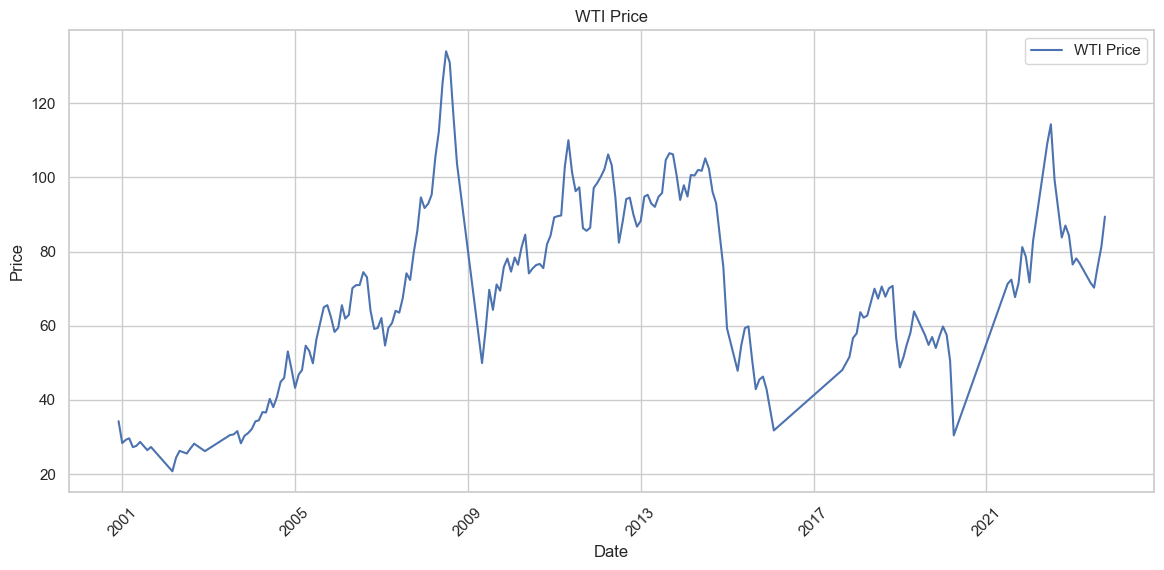

In [26]:
# plot of WTI Price
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(merged_dataset.index, merged_dataset['WTI'], label='WTI Price')
plt.title('WTI Price')
plt.xlabel('Date')
plt.ylabel('Price')
tick_dates = pd.date_range(start='2001-01-01', end='2023-01-01', freq='4YS')
ax.set_xticks(tick_dates)
ax.set_xticklabels([date.strftime('%Y') for date in tick_dates])
plt.xticks(rotation=45)
plt.legend()
plt.show()

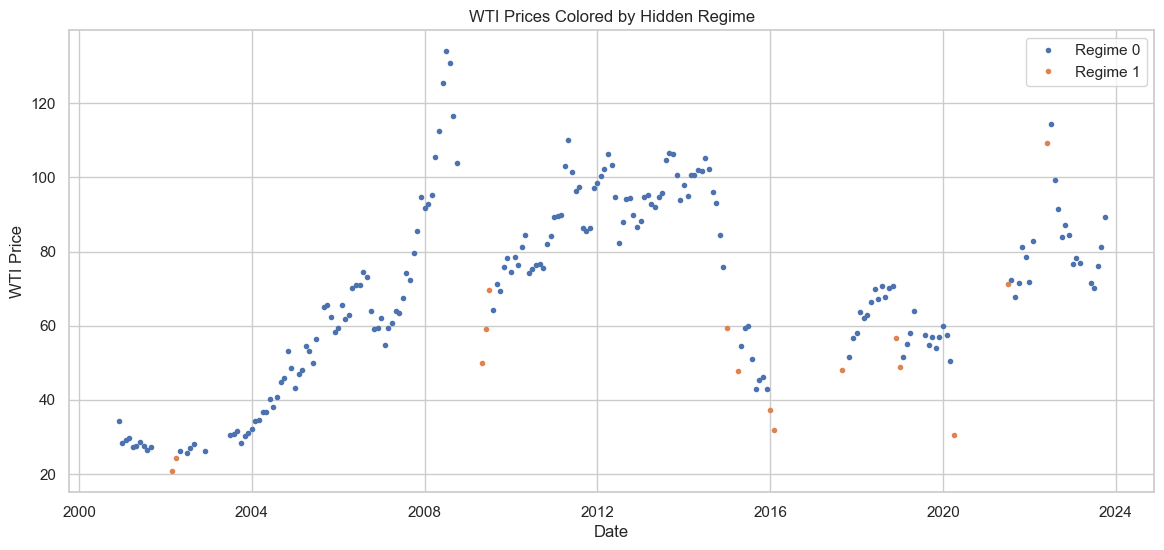

In [27]:
# Plotting regimes
fig, ax = plt.subplots(figsize=(14,6))

for i in range(model.n_components):
    state = (merged_dataset['Regime'] == i)
    ax.plot(merged_dataset.index[state], merged_dataset['WTI'][state], '.', label=f"Regime {i}")

ax.set_title("WTI Prices Colored by Hidden Regime")
ax.set_xlabel("Date")
ax.set_ylabel("WTI Price")
ax.legend()
plt.show()

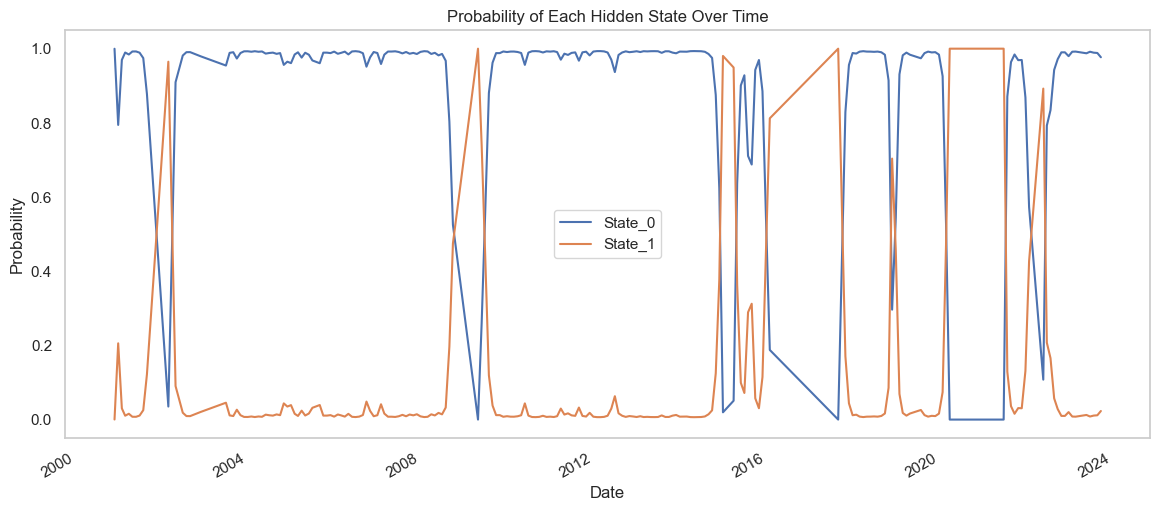

In [28]:
probabilities = model.predict_proba(merged_dataset[['WTI_log_return']])
prob_df = pd.DataFrame(probabilities, index=merged_dataset.index, columns=[f"State_{i}" for i in range(model.n_components)])

prob_df.plot(figsize=(14,6), title='Probability of Each Hidden State Over Time')
plt.xlabel("Date")
plt.ylabel("Probability")
plt.grid()
plt.show()

## **Bayesian Network Model**

In [29]:
# loading the merged dataset 
df = merged_dataset.copy()
df = df.drop(columns=["WTI"])
df = df.dropna()

# columns to discretize (excluding Regime)
features = ['GPR', 'EUI', 'CPI', 'GDP', 'RUR', 'VIX', 'DXY', 'WCEST', 'WTI_log_return']
target = ['Regime']

disc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df[features] = disc.fit_transform(df[features])

In [30]:
# splitting the dataset
train_data, test_data = train_test_split(df[features + target], test_size=0.2, random_state=42)

# structure learning (Hill-Climbing + BIC)
hc = HillClimbSearch(train_data)
best_model = hc.estimate(scoring_method=BicScore(train_data))

# defining Bayesian Network and fitting parameters
model = BayesianNetwork(best_model.edges())
model.fit(train_data, estimator=BayesianEstimator, prior_type="BDeu")

# perform inference
inference = VariableElimination(model)
regime_query = inference.map_query(variables=['Regime'], evidence={'VIX': 2})
print("Predicted regime for high VIX:", regime_query)

Eliminating: RUR: 100%|█████████████████████████| 4/4 [00:00<00:00, 3780.36it/s]

Predicted regime for high VIX: {'Regime': np.int64(0)}


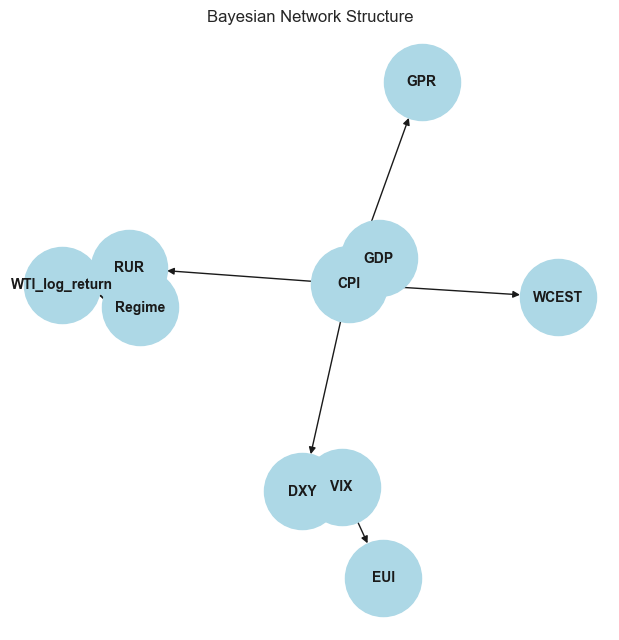

In [31]:
# plotting the network
plt.figure(figsize=(6, 6))
G = nx.DiGraph(model.edges())  # convert model edges into a networkx DiGraph

pos = nx.spring_layout(G, seed=42)  # layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, font_size=10, font_weight='bold', arrows=True)
plt.title("Bayesian Network Structure")
plt.show()

In [35]:
print("Learned structure edges:")
print(best_model.edges())

print("\nNodes:")
print(model.nodes())

print("\nEdges:")
print(model.edges())

Learned structure edges:
[('CPI', 'WCEST'), ('CPI', 'DXY'), ('CPI', 'RUR'), ('CPI', 'GPR'), ('GDP', 'CPI'), ('RUR', 'Regime'), ('VIX', 'EUI'), ('DXY', 'VIX'), ('Regime', 'WTI_log_return')]

Nodes:
['CPI', 'WCEST', 'DXY', 'RUR', 'GPR', 'GDP', 'Regime', 'VIX', 'EUI', 'WTI_log_return']

Edges:
[('CPI', 'WCEST'), ('CPI', 'DXY'), ('CPI', 'RUR'), ('CPI', 'GPR'), ('DXY', 'VIX'), ('RUR', 'Regime'), ('GDP', 'CPI'), ('Regime', 'WTI_log_return'), ('VIX', 'EUI')]


## **Step 9**

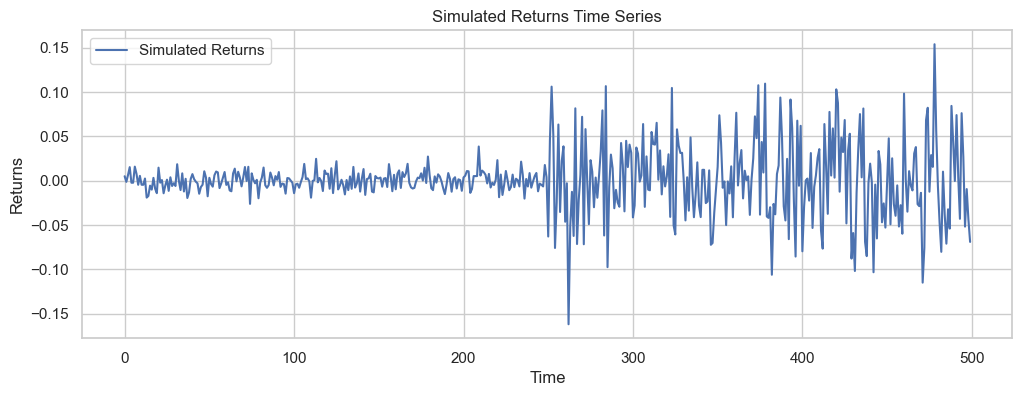

States: 1, LogL: 954.39, AIC: -1902.78
States: 2, LogL: 1187.59, AIC: -2361.18
States: 3, LogL: 1176.63, AIC: -2331.27
States: 4, LogL: 1187.59, AIC: -2345.18
States: 5, LogL: 1176.50, AIC: -2315.01

 Best model: 2 hidden states with AIC: -2361.18


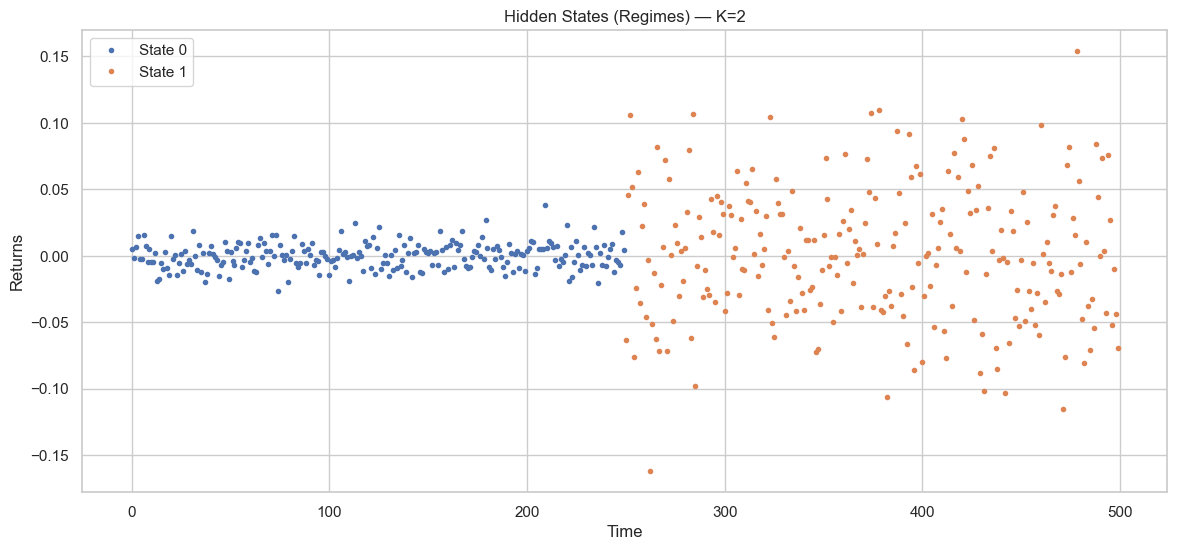


 Hidden State Parameters (Mean & Variance):
State 0: Mean = -0.00004, Variance = 0.00013
State 1: Mean = 0.00082, Variance = 0.00252

 Interpretation Tips:
- Higher variance states → volatile market regime
- Low variance states → calm regime
- Negative mean → possible bearish trend


In [15]:
# Regime-Switching HMM with Hill Climb Search

# simulating data
# Here we'll simulate simple returns data for demonstration.
np.random.seed(42)
n_samples = 500

# Simulated data: mostly stable with some high-volatility shocks
returns = np.concatenate([
    np.random.normal(0, 0.01, n_samples // 2),
    np.random.normal(0, 0.05, n_samples // 2)
]).reshape(-1, 1)

# plotting the returns
plt.figure(figsize=(12, 4))
plt.plot(returns, label="Simulated Returns")
plt.title("Simulated Returns Time Series")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend()
plt.show()

# Hill Climb search for optimal # of states
best_model = None
best_aic = np.inf
results = []

for k in range(1, 6):
    model = GaussianHMM(n_components=k, covariance_type="full", n_iter=1000, random_state=42)
    model.fit(returns)
    log_likelihood = model.score(returns)
    n_params = k - 1 + k * 2 + k * 1  # Pi + means + vars for univariate Gaussian
    aic = -2 * log_likelihood + 2 * n_params

    results.append((k, log_likelihood, aic))
    print(f"States: {k}, LogL: {log_likelihood:.2f}, AIC: {aic:.2f}")

    if aic < best_aic:
        best_aic = aic
        best_model = model

print(f"\n Best model: {best_model.n_components} hidden states with AIC: {best_aic:.2f}")

# Decode hidden states (Viterbi)
hidden_states = best_model.predict(returns)

# Add to DataFrame for plotting
df = pd.DataFrame({
    "Returns": returns.flatten(),
    "State": hidden_states
})

# plotting regimes
plt.figure(figsize=(14, 6))
for state in range(best_model.n_components):
    mask = df["State"] == state
    plt.plot(df.index[mask], df["Returns"][mask], '.', label=f"State {state}")
plt.title(f"Hidden States (Regimes) — K={best_model.n_components}")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend()
plt.show()

# inspecting latent meaning of each hidden state
print("\n Hidden State Parameters (Mean & Variance):")
for i in range(best_model.n_components):
    mean = best_model.means_[i][0]
    var = best_model.covars_[i][0][0]
    print(f"State {i}: Mean = {mean:.5f}, Variance = {var:.5f}")

print("\n Interpretation Tips:")
print("- Higher variance states → volatile market regime")
print("- Low variance states → calm regime")
print("- Negative mean → possible bearish trend")


In [41]:
np.random.seed(42)
N = 1000

# Example: A → B → C, D → E
A = np.random.binomial(1, 0.5, size=N)
B = np.logical_xor(A, np.random.binomial(1, 0.1, size=N)).astype(int)
C = np.logical_xor(B, np.random.binomial(1, 0.1, size=N)).astype(int)
D = np.random.binomial(1, 0.5, size=N)
E = np.logical_xor(D, np.random.binomial(1, 0.1, size=N)).astype(int)
data = pd.DataFrame({"A": A, "B": B, "C": C, "D": D, "E": E})

# running Hill Climb Search
scoring = BicScore(data)
hc = HillClimbSearch(data)
best_model = hc.estimate(scoring_method=scoring)

print("\nLearned structure edges:")
print(list(best_model.edges()))

# fitting CPDs using Bayesian Estimator
bn_model = BayesianNetwork(best_model.edges())
bn_model.fit(data, estimator=BayesianEstimator)

print("\nNodes:")
print(bn_model.nodes())
print("\nEdges:")
print(bn_model.edges())


# showing learned CPDs
print("\nConditional Probability Distributions:")
for cpd in bn_model.get_cpds():
    print(cpd)

  0%|                                     | 3/1000000 [00:00<6:32:37, 42.45it/s]


Learned structure edges:
[('B', 'A'), ('B', 'C'), ('E', 'D')]

Nodes:
['B', 'A', 'C', 'E', 'D']

Edges:
[('B', 'A'), ('B', 'C'), ('E', 'D')]

Conditional Probability Distributions:
+------+---------+
| B(0) | 0.50199 |
+------+---------+
| B(1) | 0.49801 |
+------+---------+
+------+---------------------+--------------------+
| B    | B(0)                | B(1)               |
+------+---------------------+--------------------+
| A(0) | 0.902378592666006   | 0.1003996003996004 |
+------+---------------------+--------------------+
| A(1) | 0.09762140733399405 | 0.8996003996003996 |
+------+---------------------+--------------------+
+------+---------------------+---------------------+
| B    | B(0)                | B(1)                |
+------+---------------------+---------------------+
| C(0) | 0.9083250743310208  | 0.11438561438561438 |
+------+---------------------+---------------------+
| C(1) | 0.09167492566897918 | 0.8856143856143857  |
+------+---------------------+-----------